<a href="https://colab.research.google.com/github/Hajara03/AI-ML-project/blob/main/notebooks/Casestudy_supervisedLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [359]:
import numpy as np
import pandas as pd

#Loading Dataset

In [360]:
df = pd.read_csv("/content/drive/MyDrive/ICT_AI ML/House_Pricing.csv")
df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


#EDA

In [361]:
#Dataset shape
df.shape

(21613, 21)

In [362]:
#statistical summary
df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [363]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [364]:
df.columns

Index(['ID', 'Date House was Sold', 'Sale Price', 'No of Bedrooms',
       'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)',
       'No of Floors', 'Waterfront View', 'No of Times Visited',
       'Condition of the House', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [365]:
#Numerical columns
df.select_dtypes(include='number').columns

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [366]:
#Categorical columns
df.select_dtypes(include='object').columns

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')

###Check Duplicate Data

In [367]:
df.duplicated().sum()

np.int64(0)

In [368]:
df=df.drop_duplicates()

###Check Null Values

In [369]:
df.isna().sum()[lambda x:x>0]

,0
Sale Price,4
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Times Visited,19489
Area of the House from Basement (in Sqft),3
Zipcode,1
Latitude,1
Longitude,1
Living Area after Renovation (in Sqft),1


In [370]:
(df.isna().sum()/len(df))*100

,0
ID,0.000000
Date House was Sold,0.000000
Sale Price,0.018507
No of Bedrooms,0.000000
No of Bathrooms,0.018507
Flat Area (in Sqft),0.041642
Lot Area (in Sqft),0.041642
No of Floors,0.000000
Waterfront View,0.000000
No of Times Visited,90.172581


In [371]:
#Removing null values in Target variable
df.dropna(subset=['Sale Price'],inplace=True)

#Train-Test Split

In [372]:
from sklearn.model_selection import train_test_split

In [373]:
X=df.drop(columns=['Sale Price'])
y=df['Sale Price']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#Data Preprocessing-
Handling Null Values

In [374]:
from sklearn.impute import KNNImputer,SimpleImputer

In [375]:
# Numerical columns
num_col_train = X_train.select_dtypes(exclude="object").columns
num_col_test = X_test.select_dtypes(exclude='object').columns

knn = KNNImputer(n_neighbors=3)

# X_train_imp = knn.fit_transform(X_train[num_col])
# X_train_imp_num = pd.DataFrame(data=X_train_imp,columns=num_col.columns,index=X.index)
#joining theses 2 lines
X_train_imp_num = pd.DataFrame(data=knn.fit_transform(X_train[num_col_train]),columns=num_col_train,index=X_train.index)
X_test_imp_num = pd.DataFrame(data=knn.transform(X_test[num_col_test]),columns=num_col_test,index=X_test.index)


# Categorical columns
cat_col_train = X_train.select_dtypes(include="object").columns
cat_col_test = X_test.select_dtypes(include='object').columns

sim = SimpleImputer(strategy="most_frequent")

X_train_imp_cat = pd.DataFrame(data=sim.fit_transform(X_train[cat_col_train]),columns=cat_col_train,index=X_train.index)
X_test_imp_cat = pd.DataFrame(data=sim.transform(X_test[cat_col_test]),columns=cat_col_test,index=X_test.index)

#Combining num and cat data
X_train_imputed = pd.concat([X_train_imp_num,X_train_imp_cat],axis=1)
X_test_imputed = pd.concat([X_test_imp_num,X_test_imp_cat],axis=1)


In [376]:
print(X_train_imputed.isna().sum().sum())
print(X_test_imputed.isna().sum().sum())
print(y_train.isna().sum().sum())
print(y_test.isna().sum().sum())

0
0
0
0


#Data Preprocessing-
Handling Outliers

In [377]:
import matplotlib.pyplot as plt
import seaborn as sns

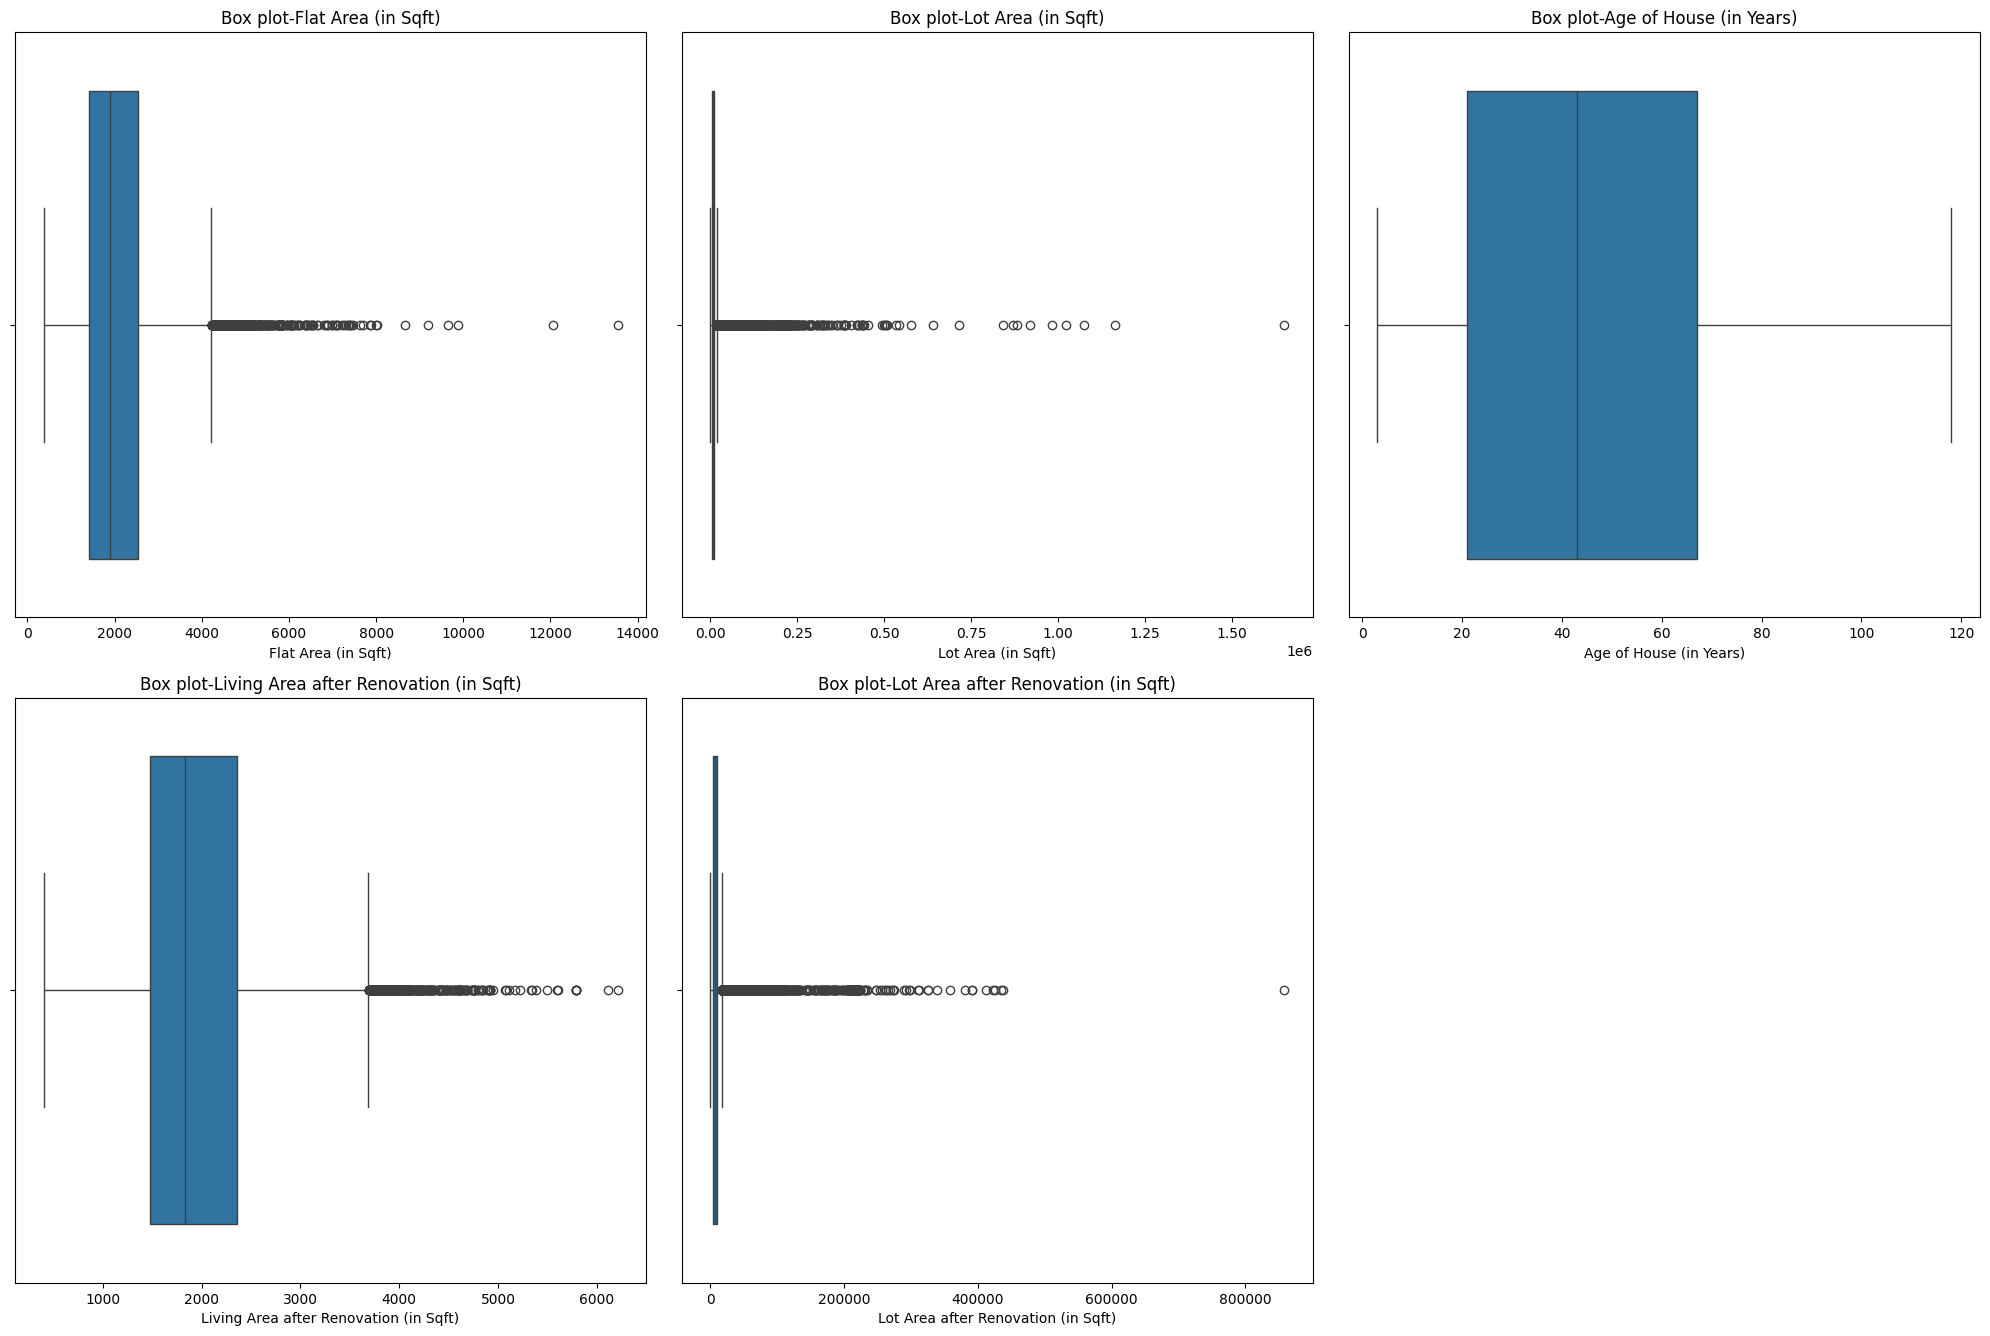

In [378]:
columns = ['Flat Area (in Sqft)','Lot Area (in Sqft)','Age of House (in Years)','Living Area after Renovation (in Sqft)','Lot Area after Renovation (in Sqft)']
plt.figure(figsize=(20,33))

for i,col in enumerate(columns):
  plt.subplot(len(columns),3,i+1)
  sns.boxplot(x=X_train_imputed[col])
  plt.title(f"Box plot-{col}")

plt.tight_layout()
plt.show()

In [379]:
# IQR Method
for col in columns:
    Q1 = X_train_imputed[col].quantile(0.25)
    Q3 = X_train_imputed[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    #Capping Method
    X_train_imputed[col] = X_train_imputed[col].clip(lower=lower, upper=upper)
    #X_test_imputed[col] = X_test_imputed[col].clip(lower=lower, upper=upper)

##Feature Extraction

In [380]:
X_train_imputed['Date House was Sold'] = pd.to_datetime(X_train_imputed['Date House was Sold'])
X_test_imputed['Date House was Sold'] = pd.to_datetime(X_test_imputed['Date House was Sold'])

#Extract month
X_train_imputed['Sale_Month'] = X_train_imputed['Date House was Sold'].dt.month
X_test_imputed['Sale_Month'] = X_test_imputed['Date House was Sold'].dt.month
#Extract Year
X_train_imputed['Sale_Year'] = X_train_imputed['Date House was Sold'].dt.year
X_test_imputed['Sale_Year'] = X_test_imputed['Date House was Sold'].dt.year

X_train_imputed.drop('Date House was Sold', axis=1, inplace=True)
X_test_imputed.drop('Date House was Sold', axis=1, inplace=True)


In [381]:
X_train_imputed.head()

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),...,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Waterfront View,No of Times Visited,Condition of the House,Sale_Month,Sale_Year
7095,8.563030e+09,3.0,2.50,2030.0,8398.0,2.0,9.0,2030.0,0.0,43.0,...,98008.0,47.6272,-122.095,2450.0,8104.0,No,Twice,Good,5,2017
18538,7.905200e+09,3.0,1.00,1230.0,7020.0,1.0,7.0,1090.0,140.0,94.0,...,98116.0,47.5719,-122.390,1390.0,5850.0,No,Twice,Fair,10,2017
20023,3.014021e+08,3.0,2.25,1481.0,2820.0,2.0,7.0,1481.0,0.0,6.0,...,98002.0,47.3457,-122.217,1481.0,3028.0,No,Twice,Fair,6,2017
6254,1.522059e+09,5.0,3.25,3320.0,11340.0,2.0,8.0,2480.0,840.0,19.0,...,98042.0,47.3904,-122.154,2330.0,8339.0,No,Twice,Good,7,2017
15383,1.630000e+08,4.0,2.50,2105.0,6093.0,2.0,8.0,2105.0,0.0,15.0,...,98042.0,47.3531,-122.147,1930.0,8022.0,No,Twice,Fair,7,2017


#Data preprocessing-
Encoding

In [382]:
from sklearn.preprocessing import LabelEncoder

In [383]:
train_cat_cols = X_train_imputed.select_dtypes(include='object').columns
for col in train_cat_cols:
    print(f"--- {col} ({X_train[col].nunique()} unique) ---")
    print(X_train[col].unique())
    print('\n')

--- Waterfront View (2 unique) ---
['No' 'Yes']


--- No of Times Visited (4 unique) ---
[nan 'Twice' 'Thrice' 'Once' 'Four']


--- Condition of the House (5 unique) ---
['Good' 'Fair' 'Okay' 'Excellent' 'Bad']




In [384]:
lb_encode=['Waterfront View']
lb=LabelEncoder()
for i in lb_encode:
  X_train_imputed[i] = lb.fit_transform(X_train_imputed[i])
  X_test_imputed[i] = lb.transform(X_test_imputed[i])

In [385]:
visit_map = {
    'Once':1,
    'Twice':2,
    'Thrice':3,
    'Four':4
}

X_train_imputed['No of Times Visited'] = X_train_imputed['No of Times Visited'].map(visit_map)
X_test_imputed['No of Times Visited'] = X_test_imputed['No of Times Visited'].map(visit_map)

In [386]:
condition_map = {
    'Bad':1,
    'Fair':2,
    'Okay':3,
    'Good':4,
    'Excellent':5
}

X_train_imputed['Condition of the House'] = X_train_imputed['Condition of the House'].map(condition_map)
X_test_imputed['Condition of the House'] = X_test_imputed['Condition of the House'].map(condition_map)

In [387]:
X_train_imputed.columns

Index(['ID', 'No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)',
       'Lot Area (in Sqft)', 'No of Floors', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)', 'Waterfront View',
       'No of Times Visited', 'Condition of the House', 'Sale_Month',
       'Sale_Year'],
      dtype='object')

#Feature Selection

In [388]:
import matplotlib.pyplot as plt
import seaborn as sns

In [389]:
train_data = X_train_imputed.copy()
train_data['Sale Price'] = y_train

In [390]:
corr = train_data.corr(numeric_only=True)

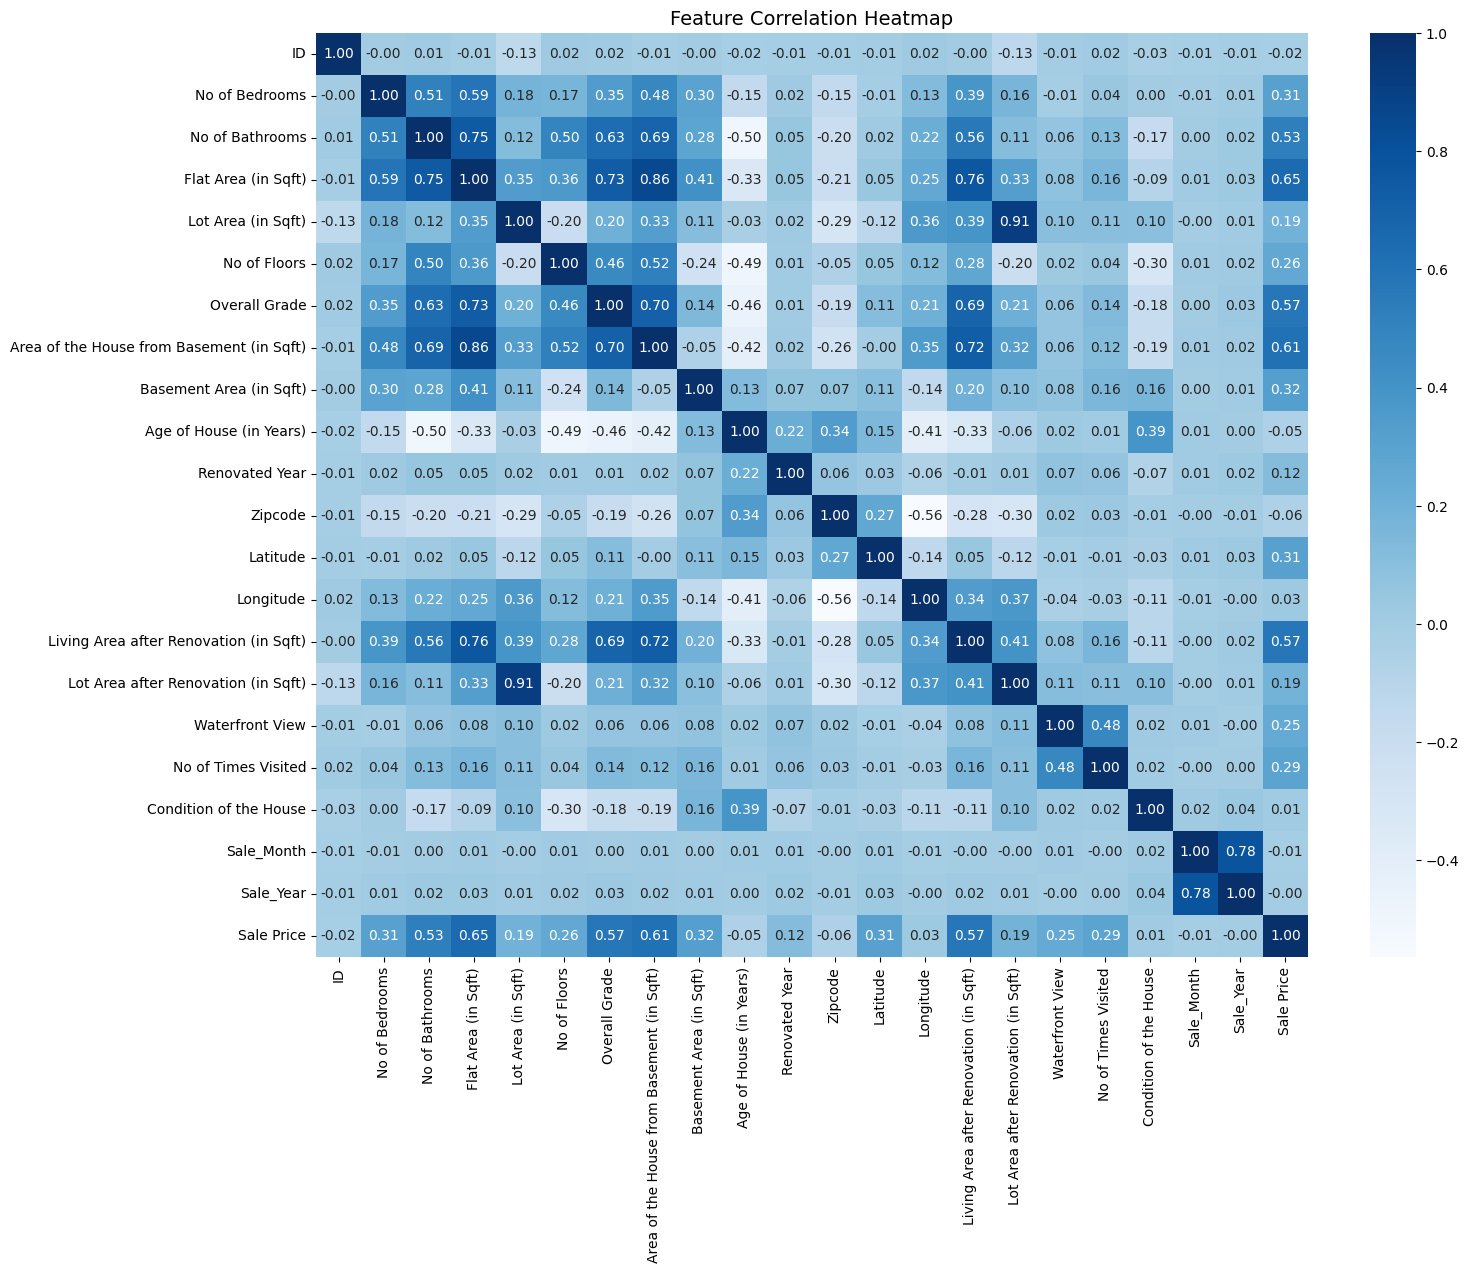

In [391]:
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.show()

In [392]:
corr['Sale Price'].loc[lambda x:x.abs()>0.3]

,Sale Price
No of Bedrooms,0.307909
No of Bathrooms,0.528063
Flat Area (in Sqft),0.646467
Overall Grade,0.574269
Area of the House from Basement (in Sqft),0.605589
Basement Area (in Sqft),0.322795
Latitude,0.307443
Living Area after Renovation (in Sqft),0.568560
Sale Price,1.000000


In [393]:
sel_col=['Overall Grade',
         'No of Bedrooms',
         'Flat Area (in Sqft)',
         'No of Bathrooms',
         'Living Area after Renovation (in Sqft)',
         'Latitude']
X_train_imputed=X_train_imputed[sel_col]
X_test_imputed=X_test_imputed[sel_col]

#Feature scaling

In [394]:
from sklearn.preprocessing import StandardScaler

In [395]:
scaler = StandardScaler()

X_train_scale = scaler.fit_transform(X_train_imputed)
X_test_scale = scaler.transform(X_test_imputed)

#Linear Regression

##Model Building

In [396]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scale, y_train)

y_pred_lr = lr.predict(X_test_scale)


##Model Evaluation

In [397]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [398]:
r2_lr = r2_score(y_test, y_pred_lr)
print(f'R2 score:  {r2_lr:.2f}')
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f'RMSE score: {rmse_lr:.2f}')
mae_lr = mean_absolute_error(y_test, y_pred_lr)
print(f'MAE:  {mae_lr:.2f}')

R2 score:  0.57
RMSE score: 249381.48
MAE:  152629.18


#KNN Regressor

##Model Building

In [399]:
from sklearn.neighbors import KNeighborsRegressor

In [400]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scale, y_train)
y_pred_knn = knn.predict(X_test_scale)

##Model Evaluation

In [401]:
r2_knn = r2_score(y_test, y_pred_knn)
print(f'R2 score:  {r2_knn:.2f}')
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
print(f'RMSE score: {rmse_knn:.2f}')
mae_knn = mean_absolute_error(y_test, y_pred_knn)
print(f'MAE:  {mae_knn:.2f}')

R2 score:  0.66
RMSE score: 222108.83
MAE:  112820.67


#Decision Tree Regressor

##Model Building

In [402]:
from sklearn.tree import DecisionTreeRegressor

In [403]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_imputed, y_train)
y_pred_dt = dt.predict(X_test_imputed)

##Model Evaluation

In [404]:
r2_dt = r2_score(y_test, y_pred_dt)
print(f'R2 score:  {r2_dt:.2f}')
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
print(f'RMSE score: {rmse_dt:.2f}')
mae_dt = mean_absolute_error(y_test, y_pred_dt)
print(f'MAE:  {mae_dt:.2f}')

R2 score:  0.52
RMSE score: 264039.15
MAE:  134911.57


#Random Forest Regressor

In [405]:
from sklearn.ensemble import RandomForestRegressor

In [406]:
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train_imputed, y_train)
y_pred_rf = rf.predict(X_test_imputed)

##Model Evaluation

In [407]:
r2_rf = r2_score(y_test, y_pred_rf)
print(f'R2 score:  {r2_rf:.2f}')
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f'RMSE score: {rmse_rf:.2f}')
mae_rf = mean_absolute_error(y_test, y_pred_rf)
print(f'MAE:  {mae_rf:.2f}')

R2 score:  0.70
RMSE score: 208947.45
MAE:  102129.60


#Conclusion

In [408]:
results = pd.DataFrame({
    'Model':['Linear Regression',
             'KNN',
             'Decision Tree',
             'Random Forest'],
    'R2':[r2_lr,r2_knn,r2_dt,r2_rf],
    'RMSE':[rmse_lr,rmse_knn,rmse_dt,rmse_rf],
    'MAE':[mae_lr,mae_knn,mae_dt,mae_rf]
})

results = results.sort_values(by='R2', ascending=False).reset_index(drop=True)
results.index += 1
results

,Model,R2,RMSE,MAE
1,Random Forest,0.700624,208947.446423,102129.598910
2,KNN,0.661721,222108.832434,112820.672004
3,Linear Regression,0.573546,249381.483189,152629.175548
4,Decision Tree,0.521943,264039.147479,134911.571418


#Saving and Loading

In [409]:
import joblib

In [410]:
joblib.dump(rf, "random_forest_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(sel_col, "selected_features.pkl")

['selected_features.pkl']

In [411]:
rf_model = joblib.load("random_forest_model.pkl")
scaler = joblib.load("scaler.pkl")
selected_features = joblib.load("selected_features.pkl")

#Prediction on New Data

In [412]:
new_data = {
    'Overall Grade': 7,
    'No of Bedrooms': 2,
    'Flat Area (in Sqft)': 1020,
    'No of Bathrooms': 0.75,
    'Living Area after Renovation (in Sqft)': 1020,
    'Latitude': 47.59
}

# Dictionary to DataFrame
new_data = pd.DataFrame([new_data])[selected_features]

prediction = rf_model.predict(new_data)

print(f"Predicted Sale Price: ${prediction[0]:,.2f}")

Predicted Sale Price: $345,494.96
